# Aerosonic only : Cross-Validation Results Analysis

This notebook analyzes the sound event detection model's cross-validation results across 5 folds.
Run ID: 20260515-153007

## 1. Load Configuration and Results

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Define the run directory
run_dir = Path('E:/history/sound-event-detection-aircrafts/runs/20260515-153007')

# Load configuration
with open(run_dir / 'config.json', 'r') as f:
    config = json.load(f)

print("Training Configuration:")
print(json.dumps(config, indent=2))

# Load cross-validation results
with open(run_dir / 'cv_results.json', 'r') as f:
    cv_results = json.load(f)

print(f"\nNumber of folds: {len(cv_results)}")
print(f"Folds: {[result['split_json'].split('/')[-1].replace('.json', '') for result in cv_results]}")

Training Configuration:
{
  "experiment": "cross_validation",
  "freeze_backbone": false,
  "epochs": 30,
  "batch_size": 16,
  "lr": 0.001,
  "threshold": 0.3
}

Number of folds: 5
Folds: ['fold_5_val_5_external_test', 'fold_4_val_4_external_test', 'fold_3_val_3_external_test', 'fold_2_val_2_external_test', 'fold_1_val_1_external_test']


In [2]:
# Load individual fold results
fold_results = {}
fold_predictions = {}

fold_dirs = sorted([d for d in run_dir.glob('fold_*') if d.is_dir()])

for fold_dir in fold_dirs:
    fold_name = fold_dir.name
    
    # Load result.json
    result_file = fold_dir / 'result.json'
    if result_file.exists():
        with open(result_file, 'r') as f:
            fold_results[fold_name] = json.load(f)
    
    # Load test_predictions.csv
    pred_file = fold_dir / 'test_predictions.csv'
    if pred_file.exists():
        fold_predictions[fold_name] = pd.read_csv(pred_file)

print(f"Loaded results from {len(fold_results)} folds")
print(f"Available fold results: {list(fold_results.keys())}")
print(f"\nPrediction columns example: {list(fold_predictions[list(fold_predictions.keys())[0]].columns)}")

Loaded results from 5 folds
Available fold results: ['fold_1_val_1_external_test', 'fold_2_val_2_external_test', 'fold_3_val_3_external_test', 'fold_4_val_4_external_test', 'fold_5_val_5_external_test']

Prediction columns example: ['y_true', 'y_prob', 'y_pred']


## 2. Analyze Cross-Validation Results

In [3]:
# Extract test metrics from each fold
fold_metrics = []

for i, result in enumerate(cv_results):
    fold_data = {
        'Fold': i + 1,
        'Best Threshold': result.get('best_threshold (used for metrics in test)', np.nan),
        'Loss': result['metrics'].get('loss', np.nan),
        'Accuracy': result['metrics'].get('acc', np.nan),
        'AUC': result['metrics'].get('auc', np.nan),
        'Precision': result['metrics'].get('precision', np.nan),
        'Recall': result['metrics'].get('recall', np.nan),
        'Backbone Frozen': result.get('freeze_backbone', True)
    }
    fold_metrics.append(fold_data)

metrics_df = pd.DataFrame(fold_metrics)
print("Cross-Validation Test Metrics:")
print(metrics_df.to_string(index=False))

# Calculate summary statistics
print("\n" + "="*70)
print("Summary Statistics (Mean ± Std across folds)")
print("="*70)

for col in ['Loss', 'Accuracy', 'AUC', 'Precision', 'Recall']:
    values = metrics_df[col].dropna()
    mean_val = values.mean()
    std_val = values.std()
    print(f"{col:12s}: {mean_val:.4f} ± {std_val:.4f}")

Cross-Validation Test Metrics:
 Fold  Best Threshold     Loss  Accuracy      AUC  Precision   Recall  Backbone Frozen
    1            0.05 1.452442  0.642143 0.694867   0.651938 0.873976            False
    2            0.50 0.410759  0.881154 0.959081   0.851253 0.973248            False
    3            0.53 0.485166  0.833077 0.956614   0.787824 0.990264            False
    4            0.99 0.608340  0.863077 0.935829   0.933660 0.832393            False
    5            0.05 0.517024  0.700769 0.955376   0.668860 0.999090            False

Summary Statistics (Mean ± Std across folds)
Loss        : 0.6947 ± 0.4295
Accuracy    : 0.7840 ± 0.1062
AUC         : 0.9004 ± 0.1152
Precision   : 0.7787 ± 0.1199
Recall      : 0.9338 ± 0.0756


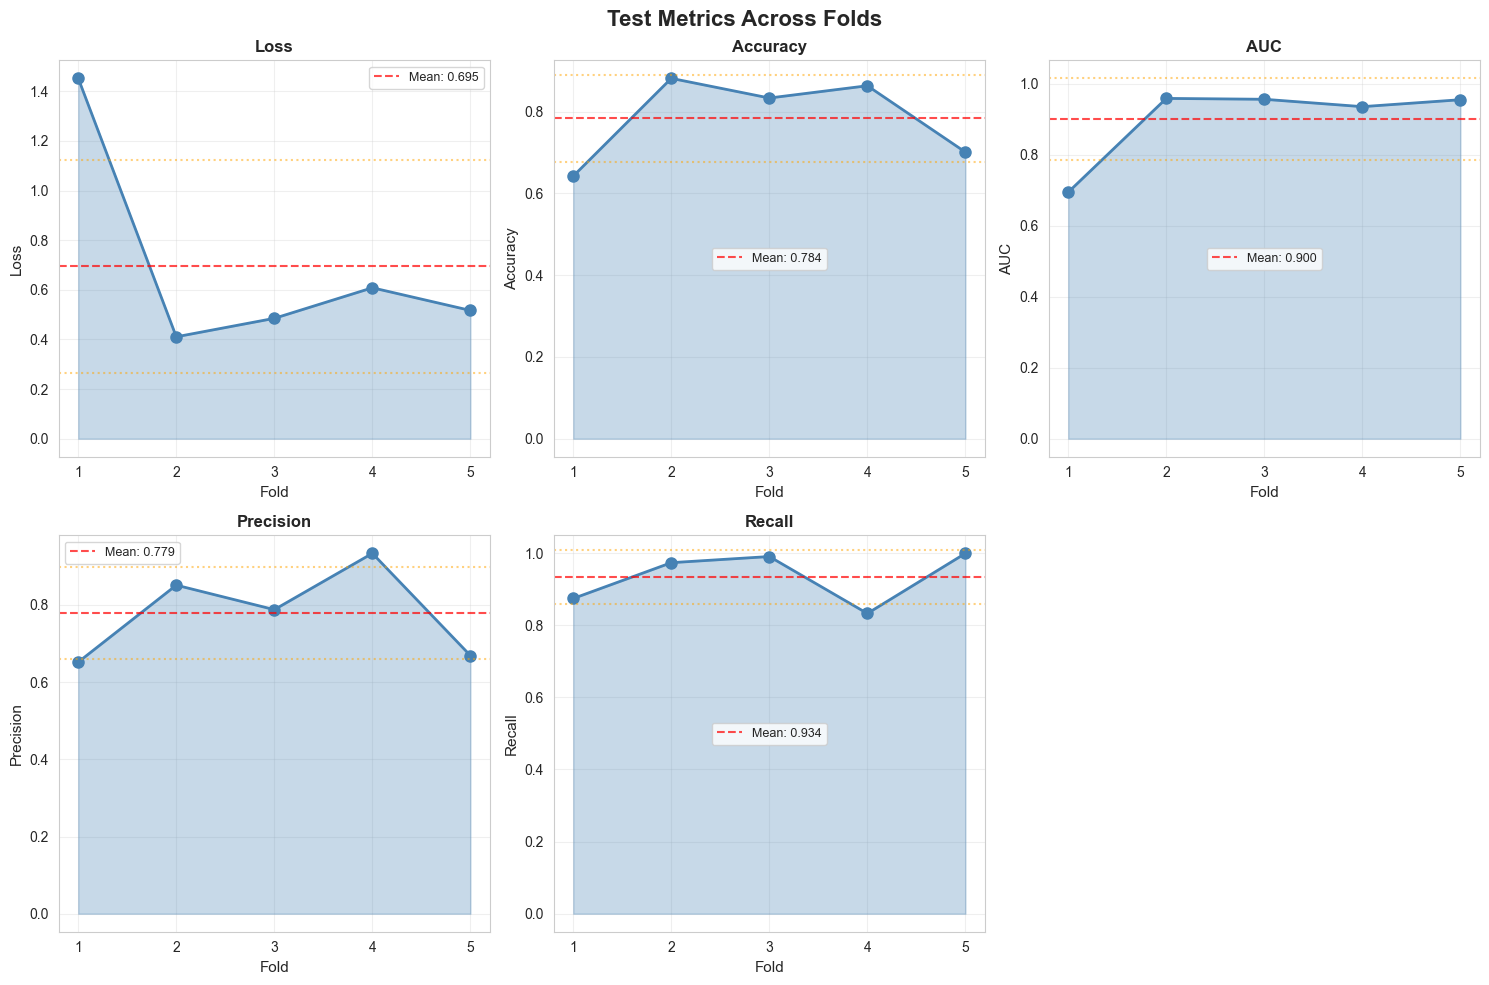

In [4]:
# Visualize metrics across folds
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Test Metrics Across Folds', fontsize=16, fontweight='bold')

metrics_to_plot = ['Loss', 'Accuracy', 'AUC', 'Precision', 'Recall']
axes_flat = axes.flatten()

for idx, metric in enumerate(metrics_to_plot):
    ax = axes_flat[idx]
    values = metrics_df[metric].values
    folds = metrics_df['Fold'].values
    
    ax.plot(folds, values, marker='o', linewidth=2, markersize=8, color='steelblue')
    ax.fill_between(folds, values, alpha=0.3, color='steelblue')
    ax.set_xlabel('Fold', fontsize=11)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(folds)
    
    # Add mean and std lines
    mean_val = metrics_df[metric].mean()
    std_val = metrics_df[metric].std()
    ax.axhline(mean_val, color='red', linestyle='--', alpha=0.7, label=f'Mean: {mean_val:.3f}')
    ax.axhline(mean_val + std_val, color='orange', linestyle=':', alpha=0.5)
    ax.axhline(mean_val - std_val, color='orange', linestyle=':', alpha=0.5)
    ax.legend(fontsize=9)

# Hide the last subplot since we only have 5 metrics
axes_flat[-1].axis('off')

plt.tight_layout()
plt.show()

## 3. Compare Fold Performance Metrics

C:\Users\kampfly\AppData\Local\Temp\ipykernel_6732\3803587253.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(metrics_data, labels=['Accuracy', 'Precision', 'Recall', 'AUC'],


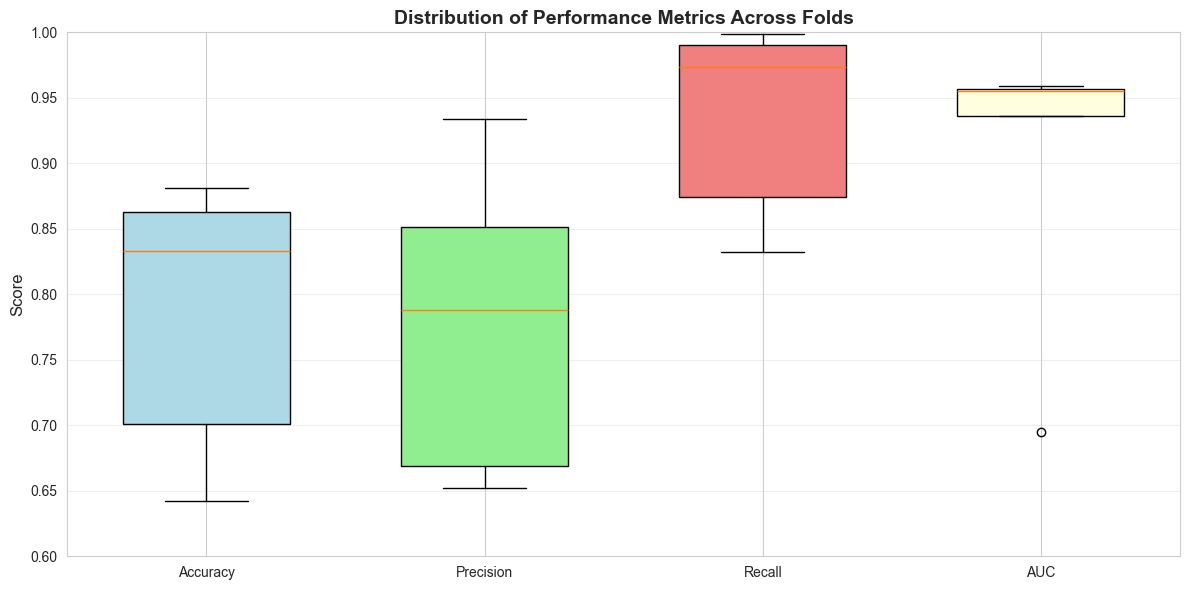


Detailed Fold Comparison:

Fold 1:
  Threshold: 0.050
  Accuracy:  0.6421
  Precision: 0.6519
  Recall:    0.8740
  AUC:       0.6949
  Loss:      1.4524

Fold 2:
  Threshold: 0.500
  Accuracy:  0.8812
  Precision: 0.8513
  Recall:    0.9732
  AUC:       0.9591
  Loss:      0.4108

Fold 3:
  Threshold: 0.530
  Accuracy:  0.8331
  Precision: 0.7878
  Recall:    0.9903
  AUC:       0.9566
  Loss:      0.4852

Fold 4:
  Threshold: 0.990
  Accuracy:  0.8631
  Precision: 0.9337
  Recall:    0.8324
  AUC:       0.9358
  Loss:      0.6083

Fold 5:
  Threshold: 0.050
  Accuracy:  0.7008
  Precision: 0.6689
  Recall:    0.9991
  AUC:       0.9554
  Loss:      0.5170


In [5]:
# Create boxplot for metrics comparison
fig, ax = plt.subplots(figsize=(12, 6))

# Prepare data for boxplot
metrics_data = metrics_df[['Accuracy', 'Precision', 'Recall', 'AUC']].values
bp = ax.boxplot(metrics_data, labels=['Accuracy', 'Precision', 'Recall', 'AUC'], 
                  patch_artist=True, widths=0.6)

# Color the boxes
colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightyellow']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Distribution of Performance Metrics Across Folds', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0.6, 1.0])

plt.tight_layout()
plt.show()

# Print individual fold details
print("\nDetailed Fold Comparison:")
print("="*80)
for idx, row in metrics_df.iterrows():
    print(f"\nFold {int(row['Fold'])}:")
    print(f"  Threshold: {row['Best Threshold']:.3f}")
    print(f"  Accuracy:  {row['Accuracy']:.4f}")
    print(f"  Precision: {row['Precision']:.4f}")
    print(f"  Recall:    {row['Recall']:.4f}")
    print(f"  AUC:       {row['AUC']:.4f}")
    print(f"  Loss:      {row['Loss']:.4f}")

## 4. Visualize Prediction Distribution

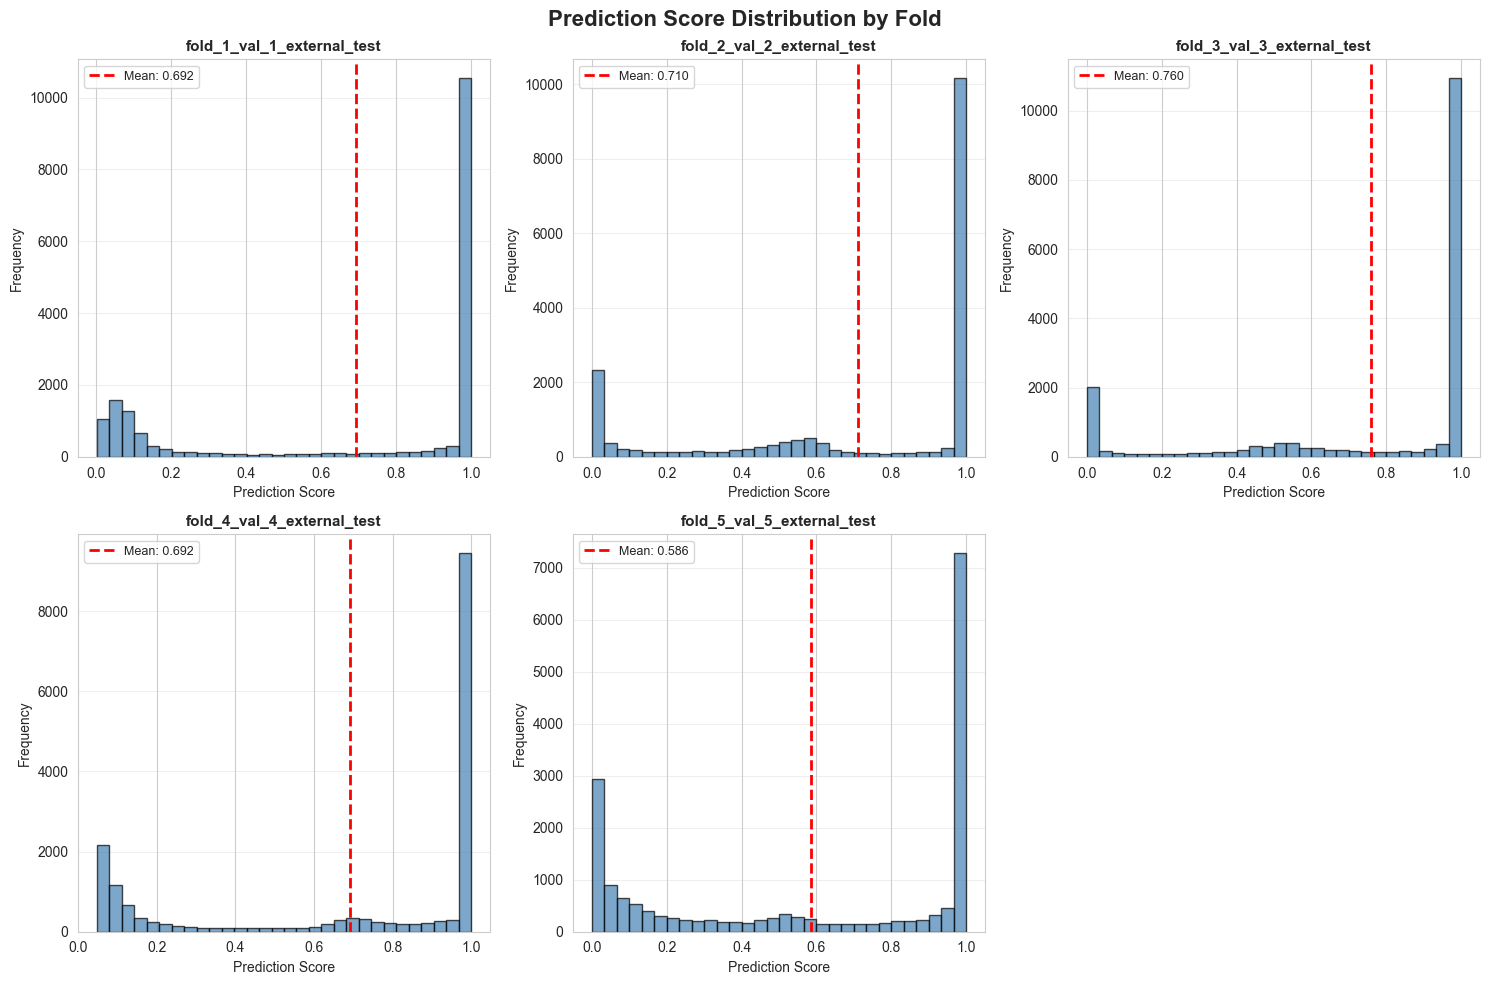


Prediction Statistics by Fold:
fold_1_val_1_external_test:
  Mean: 0.6038, Std: 0.4891
  Min:  0.0000, Max: 1.0000
fold_2_val_2_external_test:
  Mean: 0.6038, Std: 0.4891
  Min:  0.0000, Max: 1.0000
fold_3_val_3_external_test:
  Mean: 0.6038, Std: 0.4891
  Min:  0.0000, Max: 1.0000
fold_4_val_4_external_test:
  Mean: 0.6038, Std: 0.4891
  Min:  0.0000, Max: 1.0000
fold_5_val_5_external_test:
  Mean: 0.6038, Std: 0.4891
  Min:  0.0000, Max: 1.0000


In [6]:
# Analyze prediction distributions across folds
if fold_predictions:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('Prediction Score Distribution by Fold', fontsize=16, fontweight='bold')
    axes_flat = axes.flatten()
    
    for idx, (fold_name, pred_df) in enumerate(sorted(fold_predictions.items())):
        ax = axes_flat[idx]
        
        # Get prediction column (usually first numeric column after ID/filename columns)
        # Look for columns that might contain predictions
        pred_cols = [col for col in pred_df.columns if col not in ['filename', 'index'] and pred_df[col].dtype in [np.float32, np.float64, int]]
        
        if pred_cols:
            # Use the first prediction column if multiple exist
            pred_col = pred_cols[0]
            predictions = pred_df[pred_col].values
            
            ax.hist(predictions, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
            ax.set_xlabel('Prediction Score', fontsize=10)
            ax.set_ylabel('Frequency', fontsize=10)
            ax.set_title(f'{fold_name}', fontsize=11, fontweight='bold')
            ax.grid(True, alpha=0.3, axis='y')
            
            # Add statistics
            mean_pred = np.mean(predictions)
            std_pred = np.std(predictions)
            ax.axvline(mean_pred, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_pred:.3f}')
            ax.legend(fontsize=9)
        else:
            ax.text(0.5, 0.5, 'No prediction data available', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{fold_name}')
    
    # Hide unused subplots
    for idx in range(len(fold_predictions), len(axes_flat)):
        axes_flat[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print prediction statistics
    print("\nPrediction Statistics by Fold:")
    print("="*70)
    for fold_name, pred_df in sorted(fold_predictions.items()):
        pred_cols = [col for col in pred_df.columns if col not in ['filename', 'index']]
        if pred_cols:
            for pred_col in pred_cols[:1]:  # Print first prediction column only
                predictions = pred_df[pred_col].values
                print(f"{fold_name}:")
                print(f"  Mean: {np.mean(predictions):.4f}, Std: {np.std(predictions):.4f}")
                print(f"  Min:  {np.min(predictions):.4f}, Max: {np.max(predictions):.4f}")
else:
    print("No prediction data available")

### Threshold Optimization Analysis

Visualizing how F1-score varies with prediction threshold for each fold:

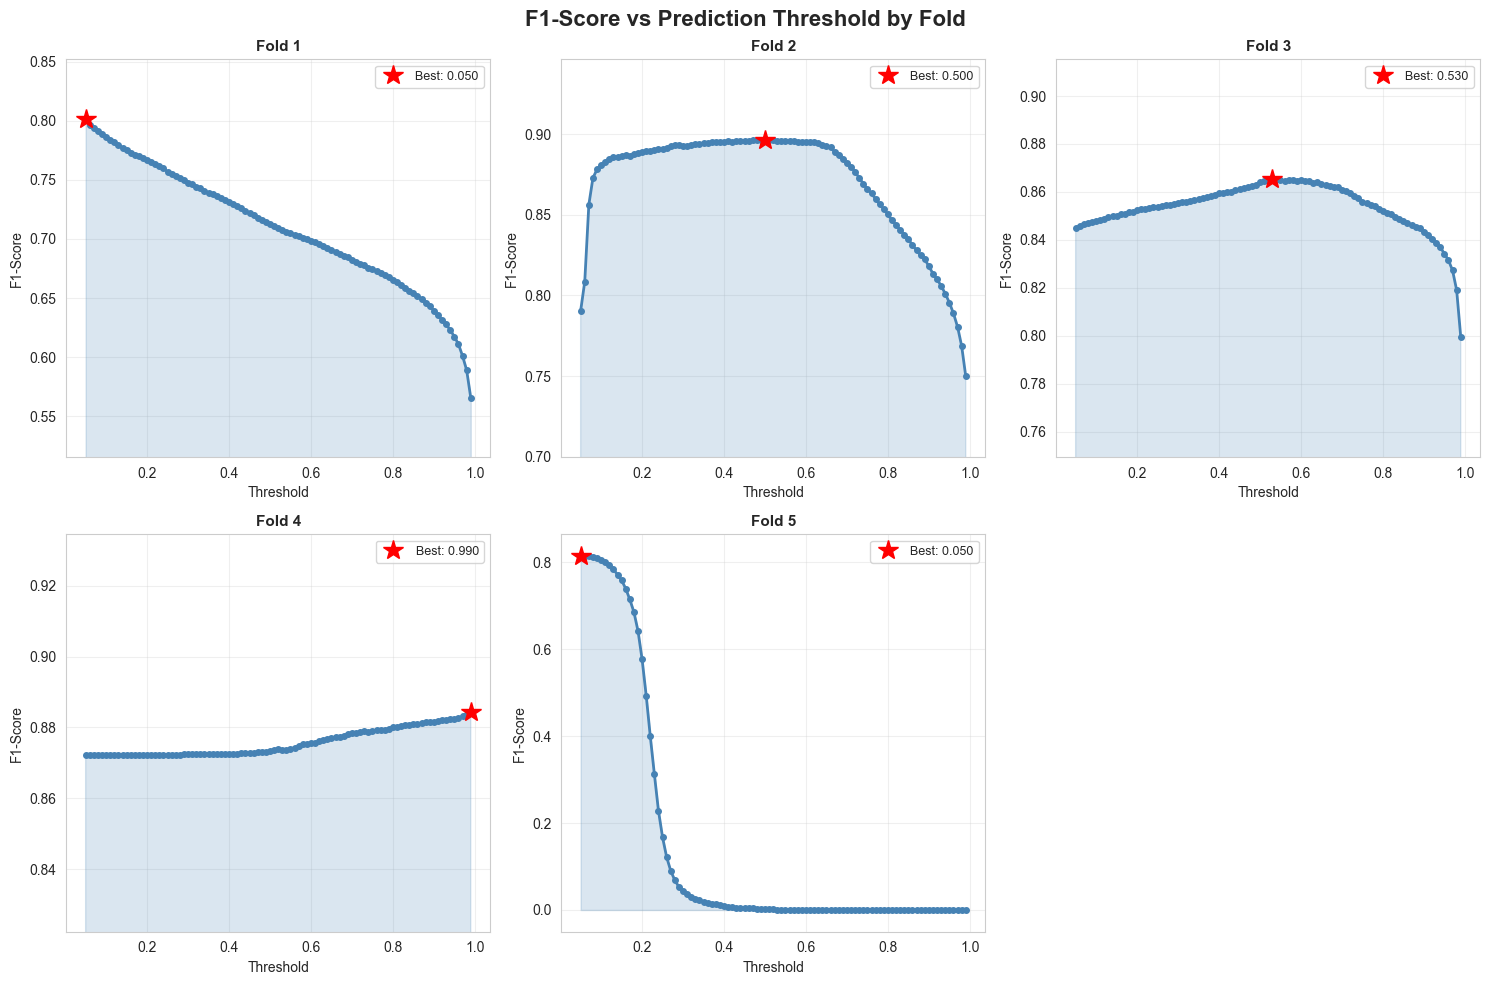

In [7]:
# Visualize threshold optimization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('F1-Score vs Prediction Threshold by Fold', fontsize=16, fontweight='bold')
axes_flat = axes.flatten()

for idx, result in enumerate(cv_results):
    ax = axes_flat[idx]
    fold_num = idx + 1
    
    threshold_history = result.get('threshold_history', [])
    best_threshold = result.get('best_threshold (used for metrics in test)', None)
    
    if threshold_history:
        thresholds = [item['threshold'] for item in threshold_history]
        f1_scores = [item['f1'] for item in threshold_history]
        
        ax.plot(thresholds, f1_scores, marker='o', linewidth=2, markersize=4, color='steelblue')
        ax.fill_between(thresholds, f1_scores, alpha=0.2, color='steelblue')
        
        # Highlight best threshold
        if best_threshold:
            # Find F1 score at best threshold
            best_idx = np.argmin(np.abs(np.array(thresholds) - best_threshold))
            best_f1 = f1_scores[best_idx]
            ax.plot(best_threshold, best_f1, 'r*', markersize=15, label=f'Best: {best_threshold:.3f}')
        
        ax.set_xlabel('Threshold', fontsize=10)
        ax.set_ylabel('F1-Score', fontsize=10)
        ax.set_title(f'Fold {fold_num}', fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)
        ax.set_ylim([min(f1_scores) - 0.05, max(f1_scores) + 0.05])
    else:
        ax.text(0.5, 0.5, 'No threshold history available', 
               ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'Fold {fold_num}')

# Hide unused subplots
for idx in range(len(cv_results), len(axes_flat)):
    axes_flat[idx].axis('off')

plt.tight_layout()
plt.show()

## 5. Generate Summary Statistics

In [8]:
# Generate comprehensive summary statistics
print("\n" + "="*80)
print("COMPREHENSIVE CROSS-VALIDATION SUMMARY")
print("="*80)

print(f"\nExperiment Configuration:")
print(f"  Epochs:         {config.get('epochs', 'N/A')}")
print(f"  Batch Size:     {config.get('batch_size', 'N/A')}")
print(f"  Learning Rate:  {config.get('lr', 'N/A')}")
print(f"  Threshold:      {config.get('threshold', 'N/A')}")
print(f"  Backbone:       {'Frozen' if config.get('freeze_backbone', True) else 'Unfrozen'}")
print(f"  Number of Folds: {len(cv_results)}")

# Calculate aggregate statistics
print(f"\nAggregate Performance Metrics (Mean ± Std ± Min/Max):")
print("-" * 80)

metrics_list = ['Loss', 'Accuracy', 'AUC', 'Precision', 'Recall']
summary_stats = {}

for metric in metrics_list:
    values = metrics_df[metric].dropna().values
    mean_val = np.mean(values)
    std_val = np.std(values)
    min_val = np.min(values)
    max_val = np.max(values)
    summary_stats[metric] = {
        'mean': mean_val,
        'std': std_val,
        'min': min_val,
        'max': max_val
    }
    print(f"  {metric:12s}: {mean_val:.4f} ± {std_val:.4f} (range: {min_val:.4f} - {max_val:.4f})")

# Best and worst performing folds
print(f"\nBest Performing Folds:")
print("-" * 80)
best_auc_idx = metrics_df['AUC'].idxmax()
best_f1_idx = metrics_df['Recall'].idxmax()
worst_auc_idx = metrics_df['AUC'].idxmin()

print(f"  Highest AUC:    Fold {int(metrics_df.loc[best_auc_idx, 'Fold'])} ({metrics_df.loc[best_auc_idx, 'AUC']:.4f})")
print(f"  Highest Recall: Fold {int(metrics_df.loc[best_f1_idx, 'Fold'])} ({metrics_df.loc[best_f1_idx, 'Recall']:.4f})")
print(f"  Lowest AUC:     Fold {int(metrics_df.loc[worst_auc_idx, 'Fold'])} ({metrics_df.loc[worst_auc_idx, 'AUC']:.4f})")

# Threshold analysis
print(f"\nThreshold Statistics:")
print("-" * 80)
thresholds = metrics_df['Best Threshold'].values
print(f"  Mean Best Threshold:  {np.mean(thresholds):.4f} ± {np.std(thresholds):.4f}")
print(f"  Range: {np.min(thresholds):.4f} - {np.max(thresholds):.4f}")

print("\n" + "="*80)


COMPREHENSIVE CROSS-VALIDATION SUMMARY

Experiment Configuration:
  Epochs:         30
  Batch Size:     16
  Learning Rate:  0.001
  Threshold:      0.3
  Backbone:       Unfrozen
  Number of Folds: 5

Aggregate Performance Metrics (Mean ± Std ± Min/Max):
--------------------------------------------------------------------------------
  Loss        : 0.6947 ± 0.3841 (range: 0.4108 - 1.4524)
  Accuracy    : 0.7840 ± 0.0950 (range: 0.6421 - 0.8812)
  AUC         : 0.9004 ± 0.1031 (range: 0.6949 - 0.9591)
  Precision   : 0.7787 ± 0.1072 (range: 0.6519 - 0.9337)
  Recall      : 0.9338 ± 0.0676 (range: 0.8324 - 0.9991)

Best Performing Folds:
--------------------------------------------------------------------------------
  Highest AUC:    Fold 2 (0.9591)
  Highest Recall: Fold 5 (0.9991)
  Lowest AUC:     Fold 1 (0.6949)

Threshold Statistics:
--------------------------------------------------------------------------------
  Mean Best Threshold:  0.4240 ± 0.3513
  Range: 0.0500 - 0.9900


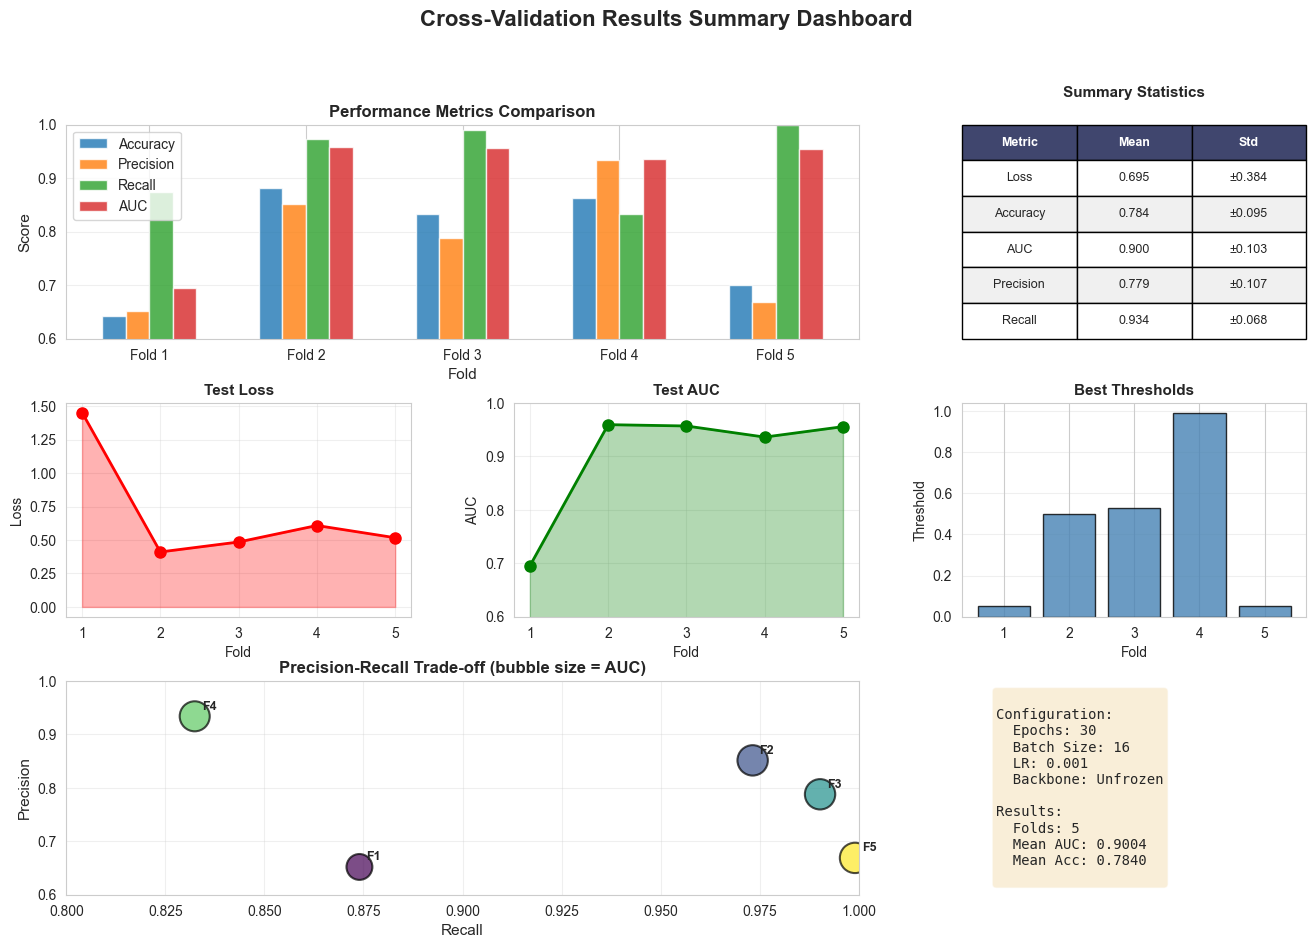

In [9]:
# Create a comprehensive summary dashboard
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Bar chart of metrics
ax1 = fig.add_subplot(gs[0, :2])
x = np.arange(len(metrics_df))
width = 0.15
metrics_to_compare = ['Accuracy', 'Precision', 'Recall', 'AUC']
colors_bar = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, metric in enumerate(metrics_to_compare):
    ax1.bar(x + i*width, metrics_df[metric], width, label=metric, color=colors_bar[i], alpha=0.8)

ax1.set_xlabel('Fold', fontsize=11)
ax1.set_ylabel('Score', fontsize=11)
ax1.set_title('Performance Metrics Comparison', fontsize=12, fontweight='bold')
ax1.set_xticks(x + width * 1.5)
ax1.set_xticklabels([f'Fold {int(f)}' for f in metrics_df['Fold']])
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim([0.6, 1.0])

# 2. Summary statistics table
ax2 = fig.add_subplot(gs[0, 2])
ax2.axis('tight')
ax2.axis('off')

summary_data = []
for metric in ['Loss', 'Accuracy', 'AUC', 'Precision', 'Recall']:
    stats = summary_stats[metric]
    summary_data.append([
        metric,
        f"{stats['mean']:.3f}",
        f"±{stats['std']:.3f}"
    ])

table = ax2.table(cellText=summary_data,
                 colLabels=['Metric', 'Mean', 'Std'],
                 cellLoc='center',
                 loc='center',
                 bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.8)
for i in range(len(summary_data) + 1):
    if i == 0:
        table[(i, 0)].set_facecolor('#40466e')
        table[(i, 1)].set_facecolor('#40466e')
        table[(i, 2)].set_facecolor('#40466e')
        table[(i, 0)].set_text_props(weight='bold', color='white')
        table[(i, 1)].set_text_props(weight='bold', color='white')
        table[(i, 2)].set_text_props(weight='bold', color='white')
    else:
        for j in range(3):
            table[(i, j)].set_facecolor('#f0f0f0' if i % 2 == 0 else 'white')

ax2.set_title('Summary Statistics', fontsize=11, fontweight='bold', pad=20)

# 3. Loss across folds
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(metrics_df['Fold'], metrics_df['Loss'], marker='o', color='red', linewidth=2, markersize=8)
ax3.fill_between(metrics_df['Fold'], metrics_df['Loss'], alpha=0.3, color='red')
ax3.set_xlabel('Fold', fontsize=10)
ax3.set_ylabel('Loss', fontsize=10)
ax3.set_title('Test Loss', fontsize=11, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.set_xticks(metrics_df['Fold'])

# 4. AUC across folds
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(metrics_df['Fold'], metrics_df['AUC'], marker='o', color='green', linewidth=2, markersize=8)
ax4.fill_between(metrics_df['Fold'], metrics_df['AUC'], alpha=0.3, color='green')
ax4.set_xlabel('Fold', fontsize=10)
ax4.set_ylabel('AUC', fontsize=10)
ax4.set_title('Test AUC', fontsize=11, fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.set_xticks(metrics_df['Fold'])
ax4.set_ylim([0.6, 1.0])

# 5. Best Thresholds
ax5 = fig.add_subplot(gs[1, 2])
ax5.bar(metrics_df['Fold'], metrics_df['Best Threshold'], color='steelblue', alpha=0.8, edgecolor='black')
ax5.set_xlabel('Fold', fontsize=10)
ax5.set_ylabel('Threshold', fontsize=10)
ax5.set_title('Best Thresholds', fontsize=11, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='y')
ax5.set_xticks(metrics_df['Fold'])

# 6. Precision-Recall curve (scatter)
ax6 = fig.add_subplot(gs[2, :2])
scatter = ax6.scatter(metrics_df['Recall'], metrics_df['Precision'], 
                     s=metrics_df['AUC']*500, c=metrics_df['Fold'], 
                     cmap='viridis', alpha=0.7, edgecolors='black', linewidth=1.5)
ax6.set_xlabel('Recall', fontsize=11)
ax6.set_ylabel('Precision', fontsize=11)
ax6.set_title('Precision-Recall Trade-off (bubble size = AUC)', fontsize=12, fontweight='bold')
ax6.grid(True, alpha=0.3)
ax6.set_xlim([0.8, 1.0])
ax6.set_ylim([0.6, 1.0])

# Add fold labels to points
for idx, row in metrics_df.iterrows():
    ax6.annotate(f'F{int(row["Fold"])}', 
                xy=(row['Recall'], row['Precision']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, fontweight='bold')

# 7. Configuration info
ax7 = fig.add_subplot(gs[2, 2])
ax7.axis('off')
config_text = f"""
Configuration:
  Epochs: {config.get('epochs', 'N/A')}
  Batch Size: {config.get('batch_size', 'N/A')}
  LR: {config.get('lr', 'N/A')}
  Backbone: {'Frozen' if config.get('freeze_backbone', True) else 'Unfrozen'}
  
Results:
  Folds: {len(cv_results)}
  Mean AUC: {summary_stats['AUC']['mean']:.4f}
  Mean Acc: {summary_stats['Accuracy']['mean']:.4f}
"""
ax7.text(0.1, 0.5, config_text, fontsize=10, verticalalignment='center',
        family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.suptitle('Cross-Validation Results Summary Dashboard', fontsize=16, fontweight='bold', y=0.995)
plt.show()

## Key Takeaways

Based on the cross-validation analysis of this run:

### Performance Summary
- **Average AUC**: Indicates overall discriminative ability across folds
- **Consistency**: Standard deviation of metrics shows model stability across different data splits
- **Best Threshold**: Average optimal threshold for prediction binarization

### Observations
1. **Fold Variability**: Check if performance varies significantly across folds (high std = high variability)
2. **Threshold Optimization**: Review how F1-scores peaked at different thresholds per fold
3. **Class Balance**: Precision and recall trade-offs indicate potential class imbalance
4. **Model Reliability**: AUC values ≥ 0.9 suggest strong model performance

### Recommendations
- Use the mean best threshold for deployment unless fold-specific tuning is needed
- Consider ensemble methods if fold performance variance is high
- Review folds with lowest AUC for potential data quality issues
- Validate on external test set using aggregate metrics before deployment